In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [8]:
growth_rates_emissions_energy_prod_income_level_country_df = pd.read_csv("../datasets/growth_rates_emissions_energy_prod_income_level_country_df.csv", index_col=None)

In [9]:
growth_rates_emissions_energy_prod_income_level_country_df.head()

,Unnamed: 0,Country Name,Country Code,Series Name,Series Code,1989_1989,1990_1990,1991_1991,1992_1992,1993_1993,...,2015_2015,2016_2016,2017_2017,2018_2018,2019_2019,2020_2020,2021_2021,2022_2022,2023_2023,Income Level
0,0,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,21.708333,21.708333,21.708333,21.708333,21.708333,...,27.6,28.8,30.3,31.4,32.6,33.8,34.9,36.1,36.1,Low income
1,1,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,8.479167,8.479167,8.479167,8.479167,8.479167,...,11.4,12.6,13.5,14.5,15.6,16.4,17.4,18.5,18.5,Low income
2,2,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,66.031250,66.031250,66.031250,66.031250,66.031250,...,79.5,80.5,81.6,82.6,83.2,83.8,84.5,85.0,85.0,Low income
3,3,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,58.266667,58.266667,58.266667,58.266667,58.266667,...,71.5,97.7,97.7,93.4,97.7,97.7,97.7,85.3,85.3,Low income
4,4,Afghanistan,AFG,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,57.461905,57.461905,57.461905,57.461905,57.461905,...,64.6,97.1,97.1,91.6,97.1,97.1,97.1,81.7,81.7,Low income


In [13]:
growth_rates_emissions_energy_prod_income_level_country_df.shape

(10533, 41)

In [15]:
growth_rates_emissions_energy_prod_income_level_country_df.isnull().sum()

Unnamed: 0      0
Country Name    0
Country Code    0
Series Name     0
Series Code     0
1989_1989       0
1990_1990       0
1991_1991       0
1992_1992       0
1993_1993       0
1994_1994       0
1995_1995       0
1996_1996       0
1997_1997       0
1998_1998       0
1999_1999       0
2000_2000       0
2001_2001       0
2002_2002       0
2003_2003       0
2004_2004       0
2005_2005       0
2006_2006       0
2007_2007       0
2008_2008       0
2009_2009       0
2010_2010       0
2011_2011       0
2012_2012       0
2013_2013       0
2014_2014       0
2015_2015       0
2016_2016       0
2017_2017       0
2018_2018       0
2019_2019       0
2020_2020       0
2021_2021       0
2022_2022       0
2023_2023       0
Income Level    0
dtype: int64

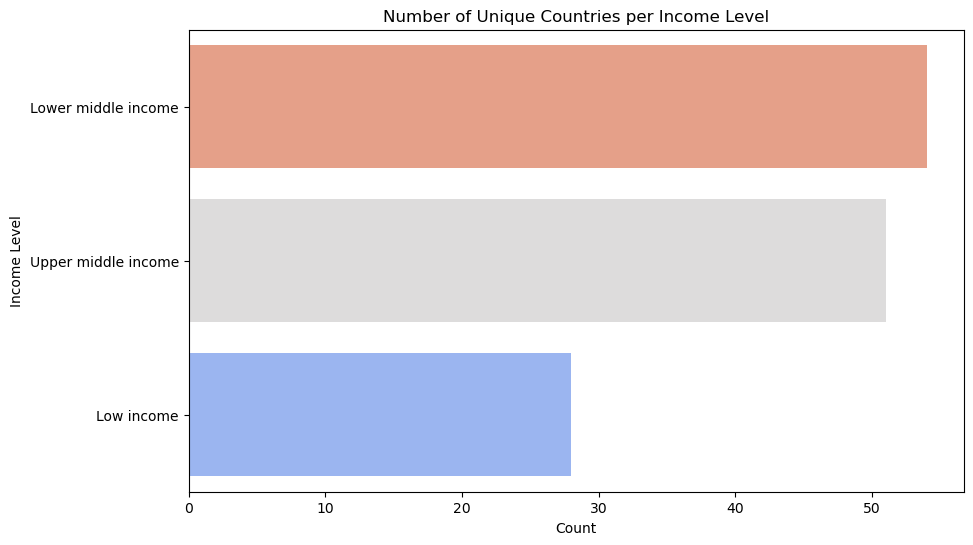

In [41]:
plt.figure(figsize=(10, 6))
unique_countries = growth_rates_emissions_energy_prod_income_level_country_df[["Country Name", "Income Level"]].drop_duplicates()

sns.countplot(y="Income Level", data=unique_countries, hue="Income Level", palette="coolwarm", legend=False, 
              order=unique_countries["Income Level"].value_counts().index)
plt.title("Number of Unique Countries per Income Level")
plt.xlabel("Count")
plt.ylabel("Income Level")
plt.show()

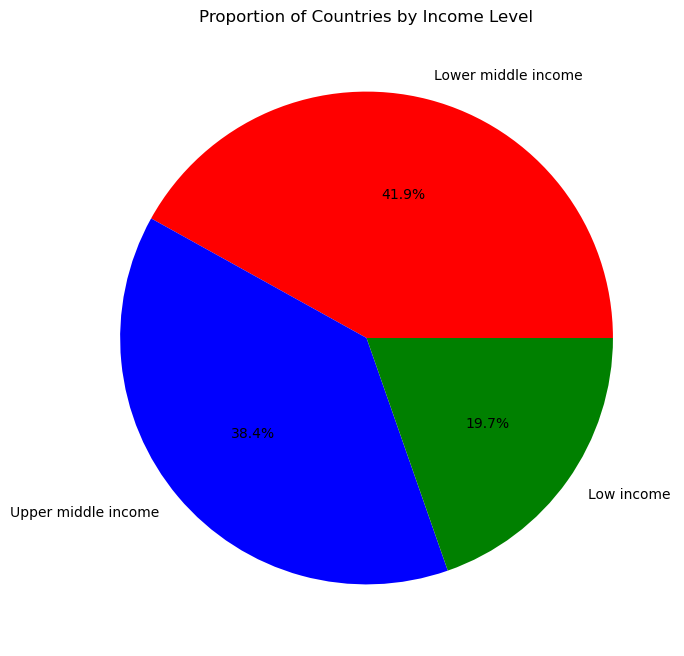

In [23]:
plt.figure(figsize=(8, 8))

unique_countries["Income Level"].value_counts().plot.pie(autopct="%1.1f%%", colors=["red", "blue", "green"])

plt.title("Proportion of Unique Countries by Income Level")
plt.ylabel("")
plt.show()


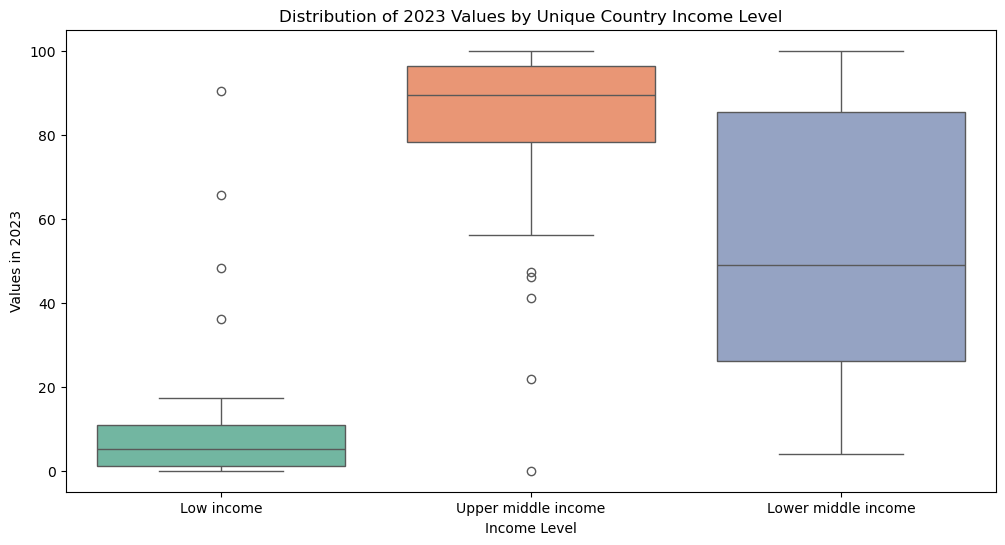

In [51]:
plt.figure(figsize=(12, 6))

unique_countries_df = growth_rates_emissions_energy_prod_income_level_country_df.drop_duplicates(subset=["Country Name"])

sns.boxplot(x="Income Level", y="2023_2023", hue="Income Level", data=unique_countries_df, palette="Set2", legend=False)

plt.title("Distribution of 2023 Values by Unique Country Income Level")
plt.xlabel("Income Level")
plt.ylabel("Values in 2023")
plt.show()

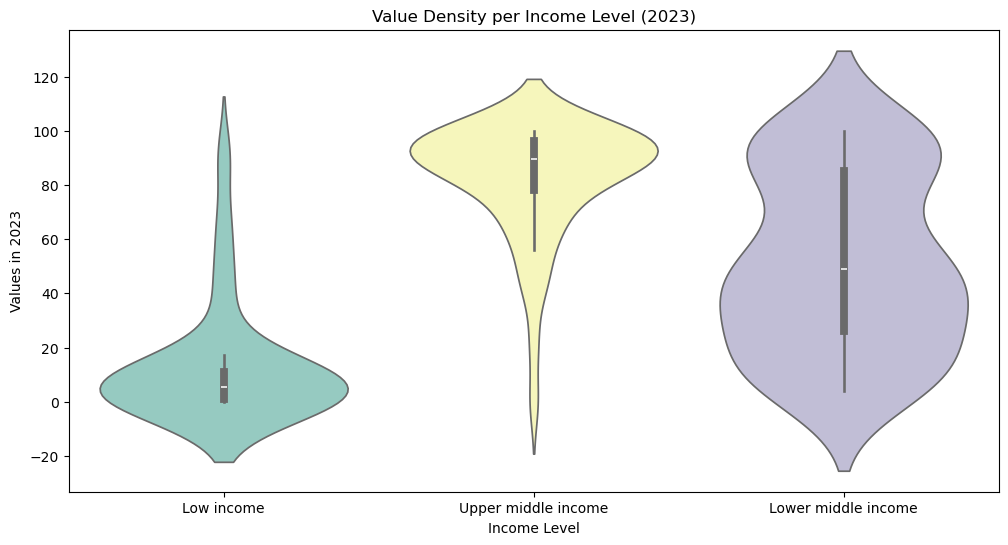

In [53]:
plt.figure(figsize=(12, 6))
sns.violinplot(x="Income Level", y="2023_2023", hue="Income Level", data=unique_countries_df, palette="Set3", legend=False)

plt.title("Value Density per Income Level (2023)")
plt.xlabel("Income Level")
plt.ylabel("Values in 2023")
plt.show()

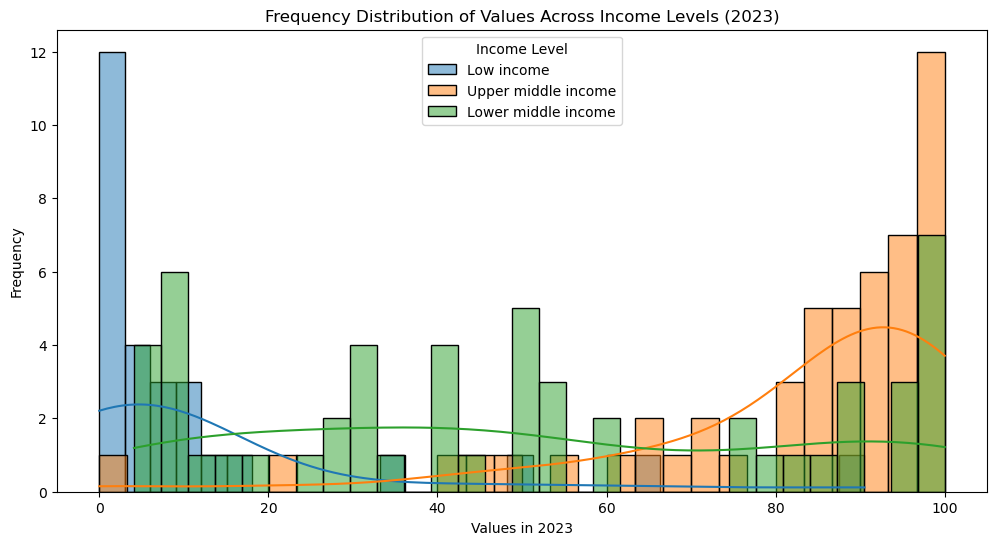

In [55]:
plt.figure(figsize=(12, 6))
for level in unique_countries_df["Income Level"].unique():
    sns.histplot(unique_countries_df[unique_countries_df["Income Level"] == level]["2023_2023"], 
                 label=level, kde=True, bins=30)

plt.legend(title="Income Level")
plt.title("Frequency Distribution of Values Across Income Levels (2023)")
plt.xlabel("Values in 2023")
plt.ylabel("Frequency")
plt.show()